SHAPE DATASET
(11430, 89)

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int6

/tmp/ipykernel_545/1319244511.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


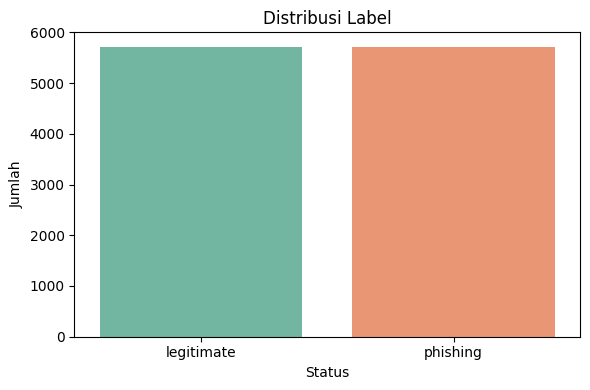


TIPE DATA
url                object
length_url          int64
length_hostname     int64
ip                  int64
nb_dots             int64
                    ...  
web_traffic         int64
dns_record          int64
google_index        int64
page_rank           int64
status             object
Length: 89, dtype: object

DATA CLEANING
Shape setelah cleaning : (11430, 89)

Label Encoding:
[0 1]

Kolom URL berhasil dihapus

OUTLIER CHECK
length_url: 620 outlier
length_hostname: 775 outlier
ratio_digits_url: 933 outlier
ratio_digits_host: 1503 outlier
nb_dots: 567 outlier


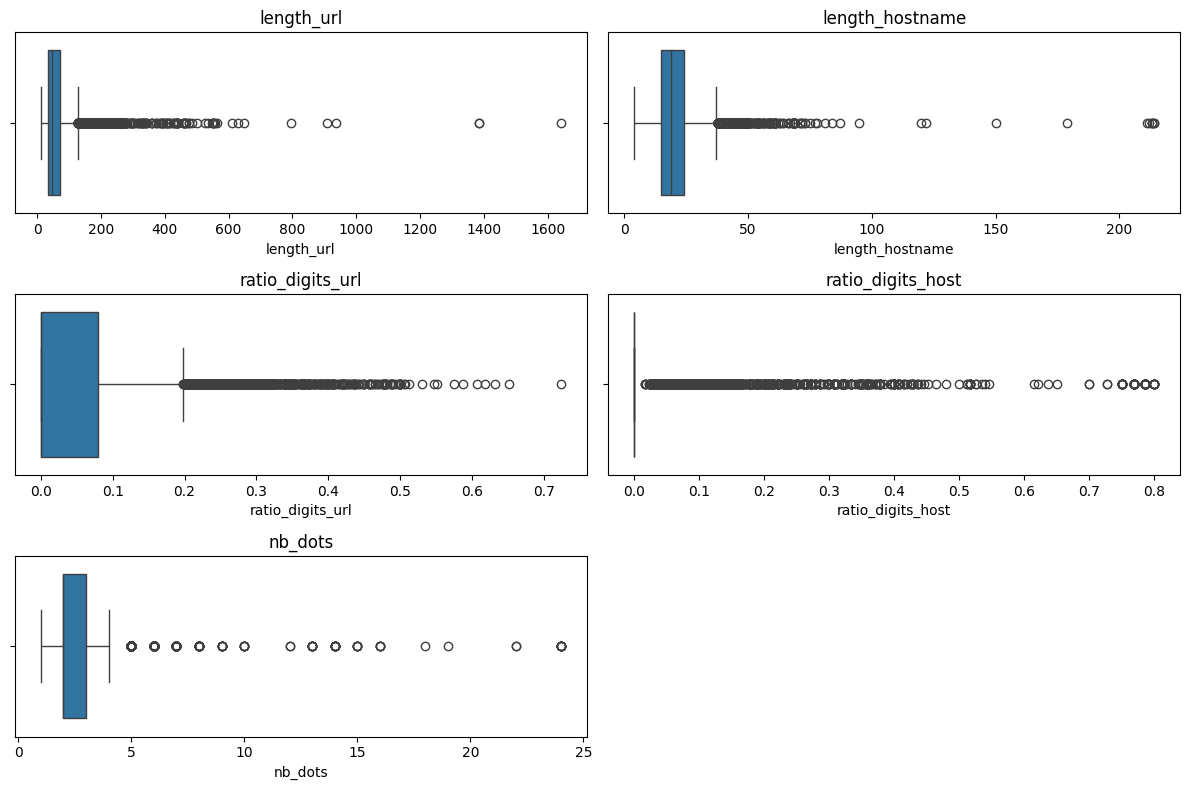


Korelasi terhadap Status
status               1.000000
ratio_digits_url     0.356395
ip                   0.321698
nb_qm                0.294319
length_url           0.248580
nb_slash             0.242270
length_hostname      0.238322
nb_eq                0.233386
ratio_digits_host    0.224335
prefix_suffix        0.214681
nb_dots              0.207029
nb_and               0.170546
nb_com               0.156284
nb_at                0.142915
https_token          0.114669
nb_subdomains        0.112891
nb_semicolumn        0.103554
nb_www              -0.443468
Name: status, dtype: float64


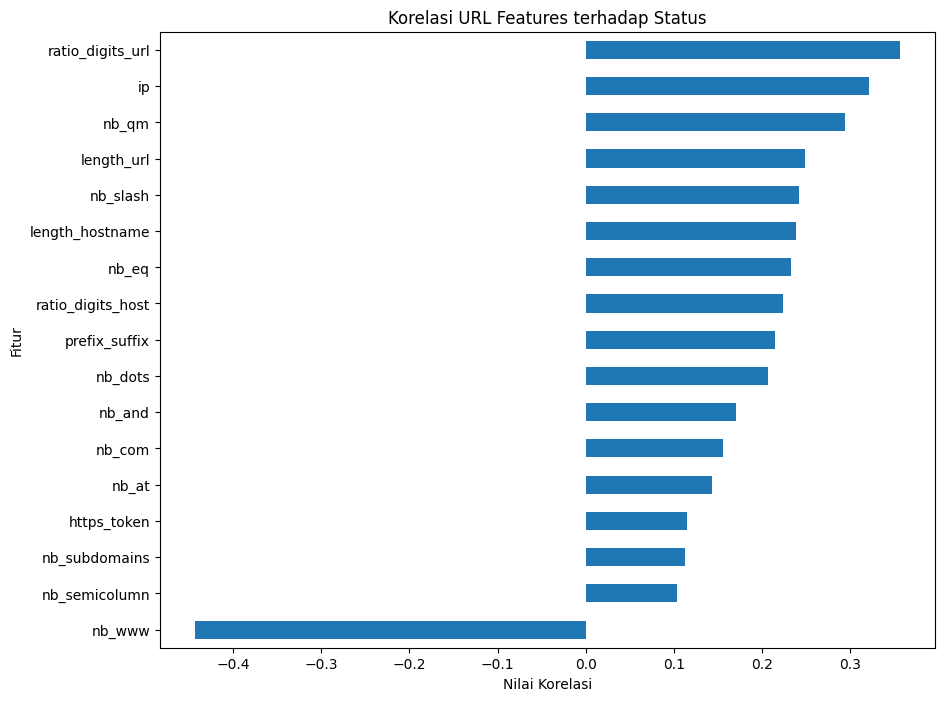


Jumlah fitur: 17
Shape X: (11430, 17)
Shape y: (11430,)

Train Shape : (9144, 17)
Test Shape  : (2286, 17)

HASIL EVALUASI
Accuracy : 0.8613298337707787
Precision: 0.8585069444444444
Recall   : 0.8652668416447944
F1 Score : 0.8618736383442266

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1143
           1       0.86      0.87      0.86      1143

    accuracy                           0.86      2286
   macro avg       0.86      0.86      0.86      2286
weighted avg       0.86      0.86      0.86      2286



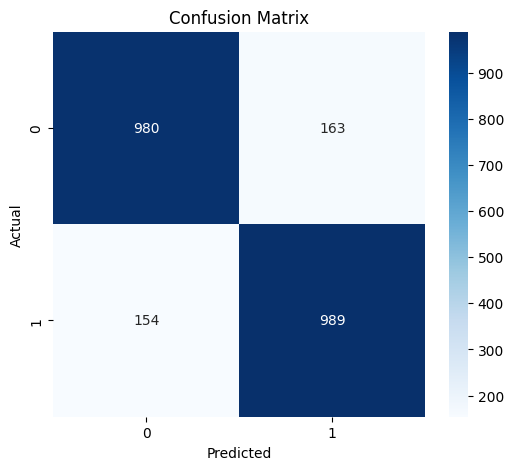


Feature Importance
              Feature  Importance
4          length_url    0.193903
0              nb_www    0.156817
7     length_hostname    0.154945
1    ratio_digits_url    0.128649
5            nb_slash    0.103560
10            nb_dots    0.052764
8   ratio_digits_host    0.039494
2                  ip    0.035792
9       prefix_suffix    0.024778
15        https_token    0.023741
3               nb_qm    0.023740
14      nb_subdomains    0.021758
6               nb_eq    0.019690
12             nb_com    0.011175
11             nb_and    0.004855
13              nb_at    0.003215
16      nb_semicolumn    0.001124


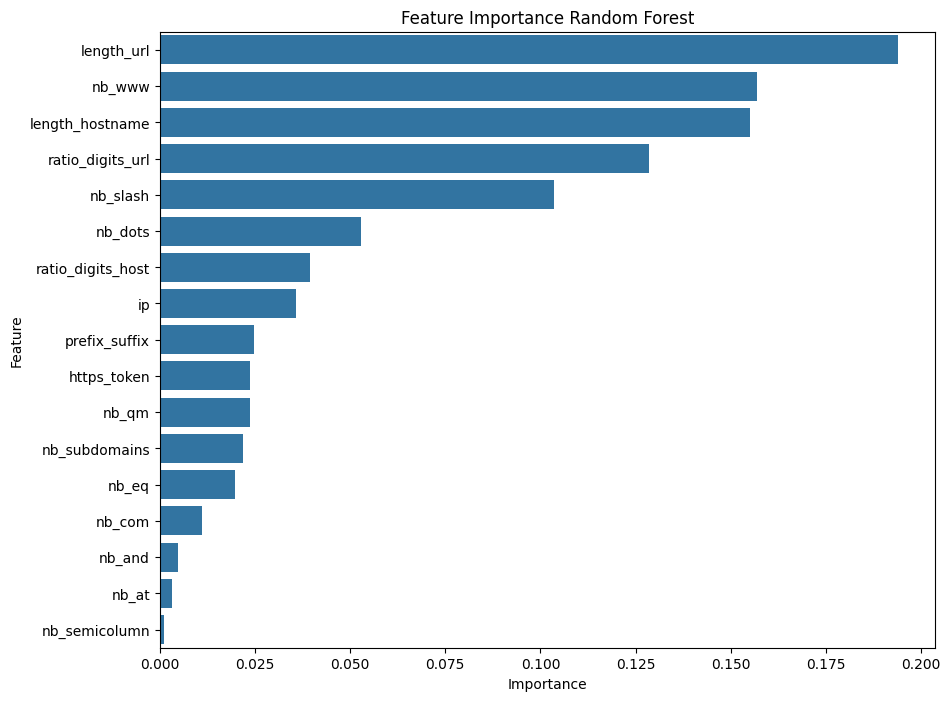


Model berhasil disimpan
Model berhasil dimuat

Prediksi Sample: 0


In [8]:
# -*- coding: utf-8 -*-
"""
PHISHING URL DETECTION
"""

# ==================================================
# DATA UNDERSTANDING
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('dataset_phishing.csv')

print("="*50)
print("SHAPE DATASET")
print("="*50)
print(df.shape)

print("\n" + "="*50)
print("INFO DATASET")
print("="*50)
df.info()

print("\n" + "="*50)
print("5 BARIS PERTAMA")
print("="*50)
print(df.head())

# ==================================================
# STATISTIK DESKRIPTIF
# ==================================================

print("\n" + "="*50)
print("STATISTIK DESKRIPTIF")
print("="*50)

print(df.describe())

# ==================================================
# MISSING VALUE
# ==================================================

print("\n" + "="*50)
print("MISSING VALUE")
print("="*50)

print(df.isnull().sum())

# ==================================================
# DUPLICATE CHECK
# ==================================================

print("\n" + "="*50)
print("DATA DUPLIKAT")
print("="*50)

duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat :", duplicate_count)

# ==================================================
# DISTRIBUSI LABEL
# ==================================================

print("\n" + "="*50)
print("DISTRIBUSI LABEL")
print("="*50)

print(df['status'].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x='status',
    data=df,
    palette='Set2'
)

plt.title('Distribusi Label')
plt.xlabel('Status')
plt.ylabel('Jumlah')

plt.tight_layout()
plt.show()

# ==================================================
# TIPE DATA
# ==================================================

print("\n" + "="*50)
print("TIPE DATA")
print("="*50)

print(df.dtypes)

# ==================================================
# DATA PREPARATION
# ==================================================

print("\n" + "="*50)
print("DATA CLEANING")
print("="*50)

# Missing Value
df.dropna(inplace=True)

# Duplicate
df.drop_duplicates(inplace=True)

print("Shape setelah cleaning :", df.shape)

# ==================================================
# ENCODING TARGET
# ==================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['status'] = le.fit_transform(df['status'])

print("\nLabel Encoding:")
print(df['status'].unique())

# ==================================================
# DROP URL
# ==================================================

if 'url' in df.columns:
    df.drop(columns=['url'], inplace=True)

print("\nKolom URL berhasil dihapus")

# ==================================================
# OUTLIER CHECK
# ==================================================

print("\n" + "="*50)
print("OUTLIER CHECK")
print("="*50)

outlier_features = [
    'length_url',
    'length_hostname',
    'ratio_digits_url',
    'ratio_digits_host',
    'nb_dots'
]

for col in outlier_features:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outlier")

# ==================================================
# VISUALISASI OUTLIER
# ==================================================

plt.figure(figsize=(12,8))

for i, col in enumerate(outlier_features, 1):

    plt.subplot(3,2,i)

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

# ==================================================
# FEATURE ENGINEERING
# ==================================================

selected_features = [
    'nb_www',
    'ratio_digits_url',
    'ip',
    'nb_qm',
    'length_url',
    'nb_slash',
    'nb_eq',
    'length_hostname',
    'ratio_digits_host',
    'prefix_suffix',
    'nb_dots',
    'nb_and',
    'nb_com',
    'nb_at',
    'nb_subdomains',
    'https_token',
    'nb_semicolumn'
]

# ==================================================
# ANALISIS KORELASI
# ==================================================

corr_url = (
    df[selected_features + ['status']]
    .corr()['status']
    .sort_values(ascending=False)
)

print("\nKorelasi terhadap Status")
print(corr_url)

# ==================================================
# VISUALISASI KORELASI
# ==================================================

plt.figure(figsize=(10,8))

corr_url.drop('status').sort_values().plot(
    kind='barh'
)

plt.title('Korelasi URL Features terhadap Status')
plt.xlabel('Nilai Korelasi')
plt.ylabel('Fitur')

plt.show()

# ==================================================
# FEATURE SELECTION
# ==================================================

X = df[selected_features]
y = df['status']

print("\nJumlah fitur:", len(selected_features))

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# ==================================================
# MODELING
# ==================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

# ==================================================
# RANDOM FOREST
# ==================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

# ==================================================
# PREDIKSI
# ==================================================

y_pred = rf.predict(X_test)

# ==================================================
# EVALUATION
# ==================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("\n" + "="*50)
print("HASIL EVALUASI")
print("="*50)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# ==================================================
# CLASSIFICATION REPORT
# ==================================================

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==================================================
# CONFUSION MATRIX
# ==================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# ==================================================
# FEATURE IMPORTANCE
# ==================================================

importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")

print(importance)

# ==================================================
# VISUALISASI FEATURE IMPORTANCE
# ==================================================

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance Random Forest'
)

plt.show()

# ==================================================
# DEPLOYMENT
# ==================================================

import pickle

with open(
    'url_phishing_model.pkl',
    'wb'
) as file:

    pickle.dump(
        rf,
        file
    )

print("\nModel berhasil disimpan")

# ==================================================
# LOAD MODEL
# ==================================================

with open(
    'url_phishing_model.pkl',
    'rb'
) as file:

    model = pickle.load(
        file
    )

print("Model berhasil dimuat")

# ==================================================
# SIMULASI PREDIKSI
# ==================================================

sample = X.iloc[[0]]

prediction = model.predict(sample)

print(
    "\nPrediksi Sample:",
    prediction[0]
)